CELL 1: INSTALL DEPENDENCIES AND IMPORT LIBRARIES

In [ ]:
!pip install scipy matplotlib pandas numpy seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, shapiro
from google.colab import drive

drive.mount('/content/drive')
print("Libraries imported and ready")

Mounted at /content/drive
Libraries imported and ready


CELL 2: LOAD HRV TABLES FROM OTHER NOTEBOOKS

In [ ]:
# Both CSV files were saved by Cell 11 of each respective notebook.
# Each row is one subject; columns are HRV parameters + Signal + Group.

df_nsr    = pd.read_csv('/content/drive/MyDrive/TFG BIO/hrv_nsr.csv')
df_mitbih = pd.read_csv('/content/drive/MyDrive/TFG BIO/hrv_mitbih.csv')

print(f"NSR-DB  : {len(df_nsr)} subjects")
print(f"MIT-BIH : {len(df_mitbih)} subjects")
print(f"\nColumns ({len(df_nsr.columns)}): {list(df_nsr.columns)}")

NSR-DB  : 18 subjects
MIT-BIH : 45 subjects

Columns (19): ['Signal', 'Group', 'Mean RR (ms)', 'Mean HR (bpm)', 'SDNN (ms)', 'RMSSD (ms)', 'pNN50 (%)', 'CV (%)', 'HRV TI', 'TINN (ms)', 'LF (ms²)', 'HF (ms²)', 'LF (n.u.)', 'HF (n.u.)', 'LF/HF', 'SD1 (ms)', 'SD2 (ms)', 'SD1/SD2', 'Area S (ms²)']


CELL 3: SHAPIRO-WILK NORMALITY TEST

In [ ]:
# Tests whether each HRV parameter follows a normal distribution in each group.
# H0: data follows a normal distribution.
# If p < 0.05 → normality rejected → Mann-Whitney U is the appropriate test.
#
# Shapiro-Wilk is preferred over Kolmogorov-Smirnov for small samples (n < 50)
# because it has higher statistical power to detect non-normality.
# Reference: Shapiro & Wilk (1965). Biometrika, 52(3-4), 591-611.
# HRV application: Garbilis & Mednieks (2024). Medicina, 60(6), 900.

params_test = [
    'SDNN (ms)', 'RMSSD (ms)', 'pNN50 (%)', 'HRV TI', 'TINN (ms)',
    'LF (ms²)',  'HF (ms²)',   'LF/HF',     'SD1 (ms)', 'SD2 (ms)'
]

print("SHAPIRO-WILK NORMALITY TEST")
print("H0: data follows a normal distribution")
print("* p < 0.05 --> normality rejected (hypothesis rejected) --> Mann-Whitney U appropriate")
print("=" * 72)
print(f"{'Parameter':<20} {'NSR W':>8} {'NSR p':>10} {'Normal?':>8} "
      f"{'MIT W':>8} {'MIT p':>10} {'Normal?':>8}")
print("-" * 72)

non_normal_count = 0
for p in params_test:
    nsr_vals = df_nsr[p].dropna().values
    mit_vals = df_mitbih[p].dropna().values
    if len(nsr_vals) < 3 or len(mit_vals) < 3:
        continue
    W_nsr, p_nsr = shapiro(nsr_vals)
    W_mit, p_mit = shapiro(mit_vals)
    nsr_normal = "YES" if p_nsr > 0.05 else "NO *"
    mit_normal = "YES" if p_mit > 0.05 else "NO *"
    if p_nsr < 0.05 or p_mit < 0.05:
        non_normal_count += 1
    print(f"{p:<20} {W_nsr:>8.3f} {p_nsr:>10.4f} {nsr_normal:>8} "
          f"{W_mit:>8.3f} {p_mit:>10.4f} {mit_normal:>8}")

print("=" * 72)
print(f"\n{non_normal_count}/{len(params_test)} parameters violate normality "
      f"in at least one group.")
print(" Mann-Whitney U applied to ALL parameters for methodological consistency.")
print("  Reference: Choi et al. (2022). Sci Rep. doi:10.1038/s41598-022-07783-3")

SHAPIRO-WILK NORMALITY TEST
H0: data follows a normal distribution
* p < 0.05 --> normality rejected (hypothesis rejected) --> Mann-Whitney U appropriate
Parameter               NSR W      NSR p  Normal?    MIT W      MIT p  Normal?
------------------------------------------------------------------------
SDNN (ms)               0.977     0.9089      YES    0.962     0.1460      YES
RMSSD (ms)              0.748     0.0003     NO *    0.890     0.0005     NO *
pNN50 (%)               0.710     0.0001     NO *    0.872     0.0001     NO *
HRV TI                  0.979     0.9432      YES    0.965     0.1937      YES
TINN (ms)               0.968     0.7499      YES    0.963     0.1598      YES
LF (ms²)                0.843     0.0067     NO *    0.577     0.0000     NO *
HF (ms²)                0.618     0.0000     NO *    0.879     0.0003     NO *
LF/HF                   0.865     0.0146     NO *    0.772     0.0000     NO *
SD1 (ms)                0.748     0.0003     NO *    0.890    

CELL 4: MANN-WHITNEY U TEST

In [ ]:
# Non-parametric test comparing two independent groups.
# H0: both groups come from the same distribution (no difference).
# p < 0.05 → statistically significant difference between NSR and MIT-BIH.
#
# Effect size: rank-biserial correlation r = 1 - 2U / (n1 * n2)
#   |r| < 0.3  → small effect
#   |r| 0.3-0.5 → medium effect
#   |r| > 0.5  → large effect
#
# References:
#   Mann & Whitney (1947). Ann. Math. Stat., 18(1), 50-60.
#   Choi et al. (2022). Sci Rep. doi:10.1038/s41598-022-07783-3

def effect_size_r(U, n1, n2):
    """Rank-biserial correlation as effect size for Mann-Whitney U."""
    return 1 - (2 * U) / (n1 * n2)

print("MANN-WHITNEY U TEST — NSR-DB vs MIT-BIH Arrhythmia Database")
print("Two-sided test  |  Significance threshold: α = 0.05")
print("Effect size: rank-biserial correlation r")
print("  |r| < 0.3 = small  |  0.3-0.5 = medium  |  > 0.5 = large")
print("=" * 92)
print(f"{'Parameter':<20} {'NSR median':>12} {'MIT median':>12} "
      f"{'U stat':>10} {'p-value':>12} {'Sig':>5} {'r':>8} {'Effect':>8}")
print("-" * 92)

resultados = []
for p in params_test:
    nsr_vals = df_nsr[p].dropna().values
    mit_vals = df_mitbih[p].dropna().values
    if len(nsr_vals) < 3 or len(mit_vals) < 3:
        continue

    U, p_val = mannwhitneyu(nsr_vals, mit_vals, alternative='two-sided')
    r        = effect_size_r(U, len(nsr_vals), len(mit_vals))

    sig = ("***" if p_val < 0.001 else
           ("**"  if p_val < 0.01  else
            ("*"  if p_val < 0.05  else "ns")))

    effect = ("large"  if abs(r) > 0.5 else
              ("medium" if abs(r) > 0.3 else "small"))

    nsr_med = np.median(nsr_vals)
    mit_med = np.median(mit_vals)

    resultados.append({
        'Parameter':   p,
        'NSR_median':  nsr_med,
        'MIT_median':  mit_med,
        'U':           U,
        'p_value':     p_val,
        'sig':         sig,
        'r':           r,
        'effect':      effect,
        'NSR_vals':    nsr_vals,
        'MIT_vals':    mit_vals
    })

    print(f"{p:<20} {nsr_med:>12.2f} {mit_med:>12.2f} "
          f"{U:>10.0f} {p_val:>12.4f} {sig:>5} {r:>8.3f} {effect:>8}")

print("=" * 92)
print("Significance: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = not significant")

MANN-WHITNEY U TEST — NSR-DB vs MIT-BIH Arrhythmia Database
Two-sided test  |  Significance threshold: α = 0.05
Effect size: rank-biserial correlation r
  |r| < 0.3 = small  |  0.3-0.5 = medium  |  > 0.5 = large
Parameter              NSR median   MIT median     U stat      p-value   Sig        r   Effect
--------------------------------------------------------------------------------------------
SDNN (ms)                   65.97        59.43        502       0.1400    ns   -0.241    small
RMSSD (ms)                  24.97        38.55        208       0.0028    **    0.486   medium
pNN50 (%)                    5.59        16.77        252       0.0203     *    0.378   medium
HRV TI                      17.48        14.79        559       0.0195     *   -0.380   medium
TINN (ms)                  257.80       195.30        536       0.0469     *   -0.323   medium
LF (ms²)                   612.73       245.16        565       0.0090    **   -0.427   medium
HF (ms²)                   226

CELL 5: BOXPLOT COMPARISON

/tmp/ipykernel_2623/27905199.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2623/27905199.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2623/27905199.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2623/27905199.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_2623/27905199.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() ha

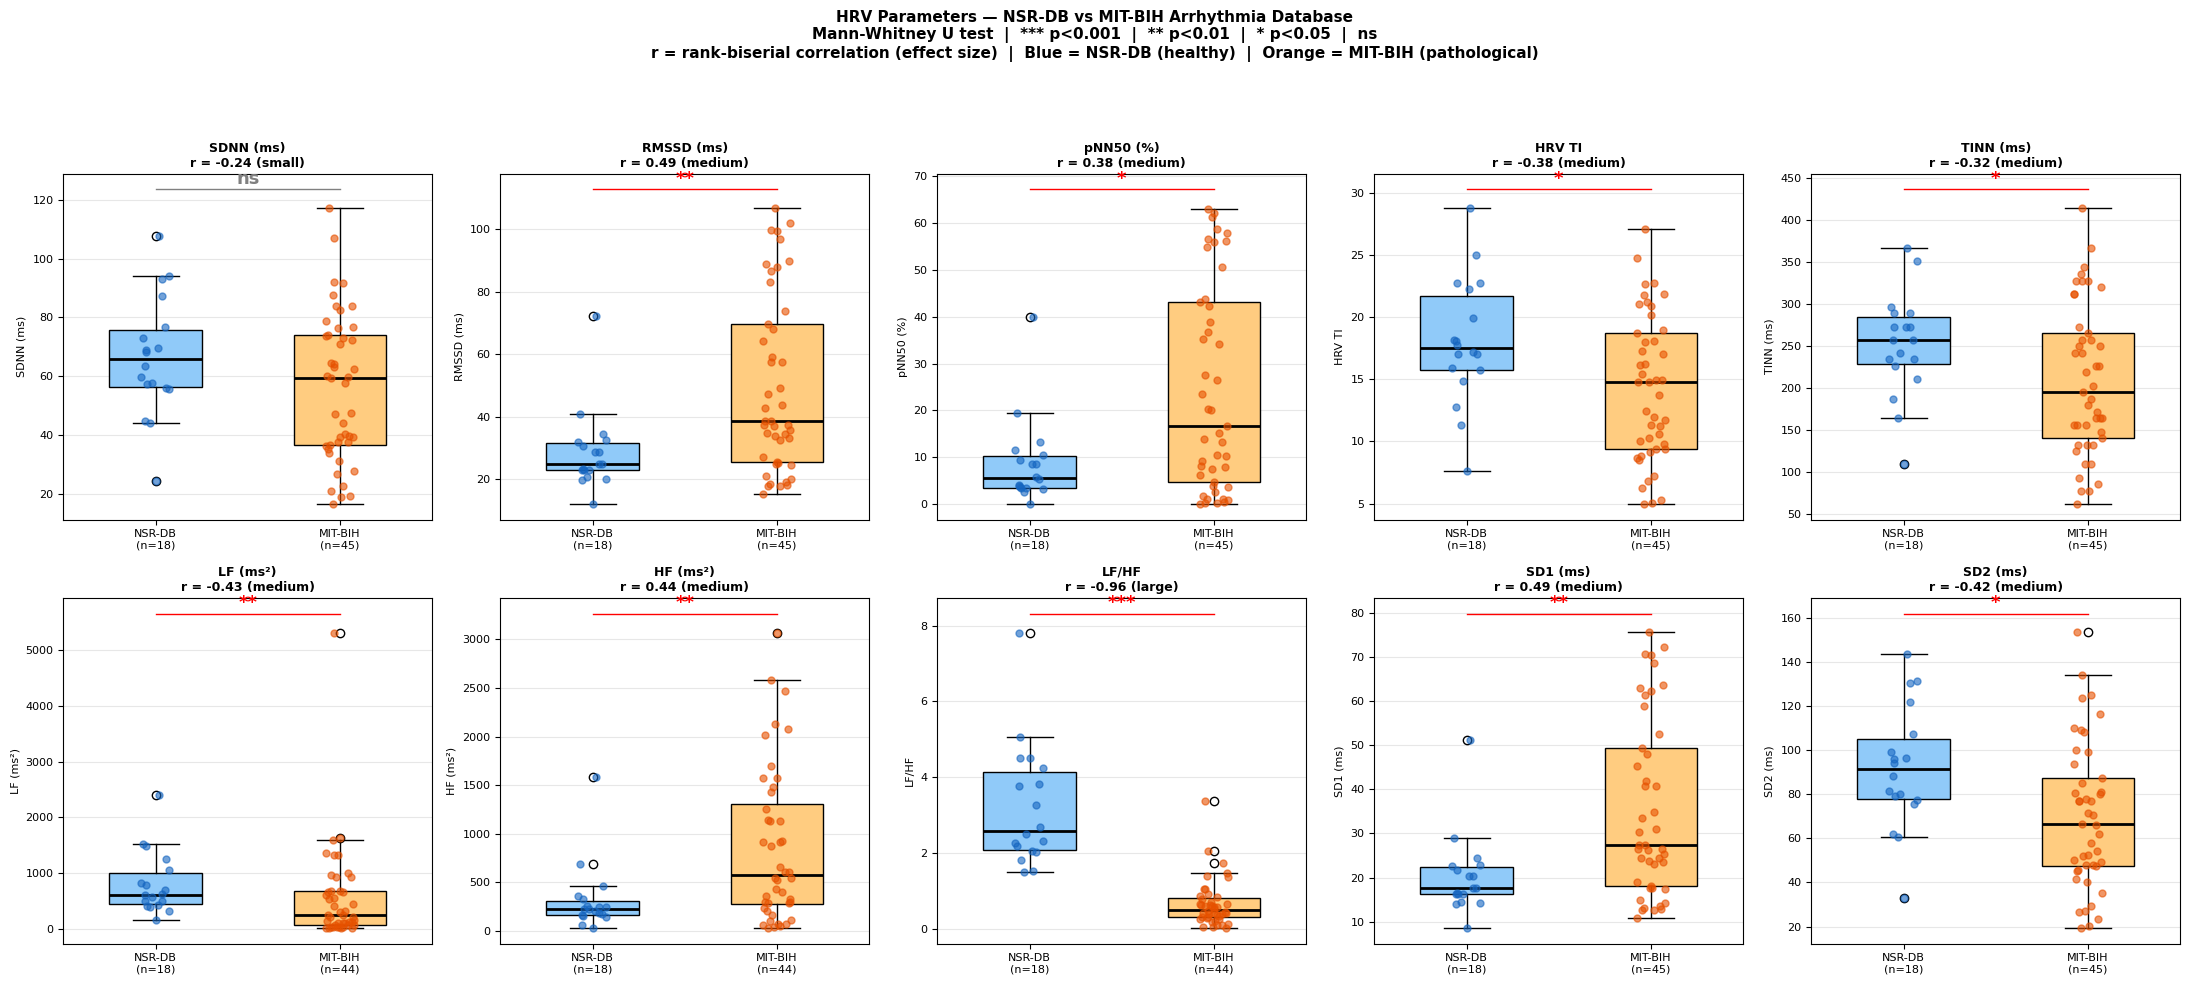

Saved: 07_statistical_comparison.png


In [ ]:
# One panel per HRV parameter.
# Blue = NSR-DB (healthy), Orange = MIT-BIH (pathological).
# Individual data points jittered for visibility.
# Significance bar and label shown above each boxplot.

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

color_nsr = '#1565C0'
color_mit = '#E65100'

for idx, res in enumerate(resultados):
    ax       = axes[idx]
    p        = res['Parameter']
    sig      = res['sig']
    data_nsr = res['NSR_vals']
    data_mit = res['MIT_vals']

    # Boxplot
    bp = ax.boxplot(
        [data_nsr, data_mit],
        labels=[f'NSR-DB\n(n={len(data_nsr)})',
                f'MIT-BIH\n(n={len(data_mit)})'],
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='black', linewidth=2)
    )
    bp['boxes'][0].set_facecolor('#90CAF9')
    bp['boxes'][1].set_facecolor('#FFCC80')

    # Individual data points (jittered horizontally)
    np.random.seed(42)   # fixed seed for reproducibility
    ax.scatter(np.ones(len(data_nsr)) + np.random.uniform(-0.08, 0.08, len(data_nsr)),
               data_nsr, color=color_nsr, alpha=0.6, s=25, zorder=3)
    ax.scatter(np.ones(len(data_mit)) * 2 + np.random.uniform(-0.08, 0.08, len(data_mit)),
               data_mit, color=color_mit, alpha=0.6, s=25, zorder=3)

    # Significance annotation above the boxplot
    y_max   = max(np.nanmax(data_nsr), np.nanmax(data_mit))
    y_min   = min(np.nanmin(data_nsr), np.nanmin(data_mit))
    y_range = y_max - y_min
    y_sig   = y_max + 0.07 * y_range
    c_sig   = 'red' if sig != 'ns' else 'gray'

    ax.plot([1, 2], [y_sig * 0.995, y_sig * 0.995],
            color=c_sig, linewidth=1)
    ax.text(1.5, y_sig, sig,
            ha='center', va='bottom',
            fontsize=13, color=c_sig, fontweight='bold')

    ax.set_title(
        f"{p}\nr = {res['r']:.2f} ({res['effect']})",
        fontsize=9, fontweight='bold', pad=5
    )
    ax.set_ylabel(p, fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(labelsize=8)

fig.suptitle(
    'HRV Parameters — NSR-DB vs MIT-BIH Arrhythmia Database\n'
    'Mann-Whitney U test  |  *** p<0.001  |  ** p<0.01  |  * p<0.05  |  ns\n'
    'r = rank-biserial correlation (effect size)  '
    '|  Blue = NSR-DB (healthy)  |  Orange = MIT-BIH (pathological)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('/content/drive/MyDrive/TFG BIO/07_statistical_comparison.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("Saved: 07_statistical_comparison.png")

CELL 6: SUMMARY TABLE - MEDIAN [IQR]

In [ ]:
# Format: Median [Q1-Q3] for each group, p-value, and significance level.

print("SUMMARY TABLE — Median [IQR] HRV parameters: NSR-DB vs MIT-BIH")
print("Mann-Whitney U test, two-sided, α = 0.05")
print("=" * 88)
print(f"{'Parameter':<20} {'NSR-DB median [IQR]':>26} "
      f"{'MIT-BIH median [IQR]':>26} {'p-value':>10} {'Sig':>5}")
print("-" * 88)

for res in resultados:
    nsr_vals        = res['NSR_vals']
    mit_vals        = res['MIT_vals']
    nsr_q1, nsr_q3 = np.percentile(nsr_vals, [25, 75])
    mit_q1, mit_q3 = np.percentile(mit_vals, [25, 75])
    nsr_str = f"{np.median(nsr_vals):.1f} [{nsr_q1:.1f}–{nsr_q3:.1f}]"
    mit_str = f"{np.median(mit_vals):.1f} [{mit_q1:.1f}–{mit_q3:.1f}]"
    print(f"{res['Parameter']:<20} {nsr_str:>26} "
          f"{mit_str:>26} {res['p_value']:>10.4f} {res['sig']:>5}")

print("=" * 88)
print("IQR = interquartile range [Q1–Q3]")
print("Significance: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = not significant")
print("\nReferences:")
print("  Mann-Whitney U: Choi et al. (2022). Sci Rep. 10.1038/s41598-022-07783-3")
print("  Shapiro-Wilk  : Shapiro & Wilk (1965). Biometrika, 52(3-4), 591-611.")
print("  HRV standards : Task Force ESC/NASPE (1996). Circulation, 93(5), 1043-1065.")

SUMMARY TABLE — Median [IQR] HRV parameters: NSR-DB vs MIT-BIH
Mann-Whitney U test, two-sided, α = 0.05
Parameter                   NSR-DB median [IQR]       MIT-BIH median [IQR]    p-value   Sig
----------------------------------------------------------------------------------------
SDNN (ms)                      66.0 [56.3–75.8]           59.4 [36.7–74.0]     0.1400    ns
RMSSD (ms)                     25.0 [22.9–31.6]           38.5 [25.7–69.6]     0.0028    **
pNN50 (%)                        5.6 [3.5–10.2]            16.8 [4.8–43.0]     0.0203     *
HRV TI                         17.5 [15.8–21.7]            14.8 [9.4–18.7]     0.0195     *
TINN (ms)                   257.8 [228.6–285.2]        195.3 [140.6–265.6]     0.0469     *
LF (ms²)                    612.7 [445.6–993.9]         245.2 [69.1–685.2]     0.0090    **
HF (ms²)                    226.8 [165.6–314.1]       574.9 [275.2–1302.9]     0.0071    **
LF/HF                             2.6 [2.1–4.1]              0.5 [0.3–0